In [1]:
import os
import random
import numpy as np
import matplotlib.pyplot as plt
from datetime import datetime
import torch
from sklearn import metrics
from BattNN import BattNN
import argparse
import copy

# reproducibility
random.seed(2022)
np.random.seed(2022)

class NPZData:
    def __init__(self, npz_dir='../../dataset/', n=50, length=50, date_fmt="%d-%b-%Y %H:%M:%S"):
        """
        npz_dir: folder containing run_XXX.npz files with arrays 'time','voltage','current','date'
        n:       how many runs to use for training
        length:  how many timesteps to crop each run to for train data
        date_fmt: format string for parsing the saved date field
        """
        self.npz_dir = npz_dir
        all_files = sorted(f for f in os.listdir(npz_dir)
                           if f.startswith('run_') and f.endswith('.npz'))
        admitted = []
        removed = []

        # 1) Filter out runs with any negative current
        for fname in all_files:
            data = np.load(os.path.join(npz_dir, fname))
            curr = np.asarray(data['current'])
            if np.any(curr < 0):
                removed.append(fname)
            else:
                admitted.append(fname)

        # Report removed runs
        if removed:
            print("Removed runs due to negative current:", removed)
        else:
            print("No runs removed due to negative current.")

        # 2) Parse date and sort admitted chronologically
        dated_files = []
        for fname in admitted:
            data = np.load(os.path.join(npz_dir, fname))
            date_str = str(data['date'].item())
            dt = datetime.strptime(date_str, date_fmt)
            dated_files.append((fname, dt))

        dated_files.sort(key=lambda x: x[1])
        sorted_files = [fname for fname, _ in dated_files]

        # 3) Split first n chronologically into train, rest into test
        self.train_files = sorted_files[:n]
        self.test_files  = sorted_files[n:]
        self.length      = length

    def load_train_data(self):
        """Return (I, V, dates) arrays for training."""
        I, V, D = [], [], []
        for fname in self.train_files:
            data = np.load(os.path.join(self.npz_dir, fname))
            curr = data['current'][:self.length].astype(np.float32)
            volt = data['voltage'][:self.length].astype(np.float32)
            date = str(data['date'].item())
            if curr.size == self.length and volt.size == self.length:
                I.append(curr)
                V.append(volt)
                D.append(date)
        return np.stack(I), np.stack(V), D

    def yield_test_data(self):
        """Yield (current, voltage, date) for each test run."""
        for fname in self.test_files:
            data = np.load(os.path.join(self.npz_dir, fname))
            curr = data['current'].astype(np.float32)
            volt = data['voltage'].astype(np.float32)
            date = str(data['date'].item())
            yield curr, volt, date


def print_date_range(npz_dir):
    dates = []
    for fname in os.listdir(npz_dir):
        if not fname.startswith("run_") or not fname.endswith(".npz"):
            continue
        data = np.load(os.path.join(npz_dir, fname))
        # load the 0-d string array and parse it
        date_str = str(data['date'].item())
        # adjust the format if your dates differ
        dt = datetime.strptime(date_str, "%d-%b-%Y %H:%M:%S")
        dates.append(dt)
    if not dates:
        print("No runs found in", npz_dir)
        return
    earliest = min(dates)
    latest   = max(dates)
    print("Date range across all runs:")
    print("  Earliest:", earliest.strftime("%d-%b-%Y %H:%M:%S"))
    print("  Latest:  ", latest  .strftime("%d-%b-%Y %H:%M:%S"))


def eval_metrics(y_true, y_pred):
    MAE  = metrics.mean_absolute_error     (y_true, y_pred)
    MAPE = metrics.mean_absolute_percentage_error(y_true, y_pred)
    MSE  = metrics.mean_squared_error      (y_true, y_pred)
    RMSE = np.sqrt(MSE)
    return [MAE, MAPE, MSE, RMSE]

def train(args, train_x, train_y, model_name='BattNN'):
    # 1) Create model
    if model_name == 'BattNN':
        model = BattNN(args)
        print("Selected model: BattNN")
    elif model_name == 'LSTM':
        model = LSTM(args)
        print("Selected model: LSTM")
    else:
        raise ValueError(f"Unsupported model: {model_name}")

    args.batch_size = train_x.shape[0]
    x0 = torch.tensor(args.x0, dtype=torch.float32, device=args.device)
    model.init_x = x0.repeat(args.batch_size, 1)
    print(f"Training on {train_x.shape[0]} runs")
    
    # 2) Package data into the model
    x_tensor = torch.from_numpy(train_x.astype(np.float32))
    y_tensor = torch.from_numpy(train_y.astype(np.float32))
    model.get_data(x=x_tensor, label=y_tensor)

    # 3) Train
    model.train()
    return model  # in case you want to keep it around


def test(args, data_iter, model_name='BattNN', plot_n=5):
    """
    Evaluate a trained BattNN/LSTM on arbitrary-length sequences,
    by loading the original checkpoint and then slicing init_x to batch=1.
    """
    # 1) Instantiate & load the saved checkpoint (uses original args so save_name matches)
    if model_name == 'BattNN':
        model = BattNN(args)
    elif model_name == 'LSTM':
        model = LSTM(args)
    else:
        raise ValueError(f"Unsupported model: {model_name}")
    model.load_model()

    # 2) For inference, we only want batch_size=1, so slice off rows of init_x
    #    (init_x was created in __init__ as [batch_size,4], so we keep just the first one)
    model.init_x = model.init_x[:1, :]

    errors = []
    for i, (curr, volt, date) in enumerate(data_iter(), start=1):
        # 3) Build a [1 x T] tensor from the full-length current trace
        c_t = torch.from_numpy(curr.astype(np.float32)).view(1, -1)

        # 4) Predict a [1 x T] voltage trace
        pred, _ = model.predict(c_t)
        pred = pred.detach().cpu().numpy().ravel()

        # 5) Sanity check – they must match length exactly
        assert pred.shape[0] == volt.shape[0], (
            f"Length mismatch: pred={pred.shape[0]}, true={volt.shape[0]}"
        )

        # 6) Compute metrics on the full trace
        met = eval_metrics(volt, pred)
        errors.append(met)

        # 7) Plot first few runs with twin axes and date tick
        if i <= plot_n:
            fig, ax1 = plt.subplots()
            ax2 = ax1.twinx()

            ax1.plot(curr, color='g', label='Current')
            ax1.set_ylabel('Current (A)', color='g')
            ax1.set_xticks([0])
            ax1.set_xticklabels([date], rotation=45, ha='right')

            ax2.plot(volt, '-r', label='Voltage (true)')
            ax2.plot(pred, '--r', label='Voltage (pred)')
            ax2.set_ylabel('Voltage (V)', color='r')

            # merge legends
            l1, lab1 = ax1.get_legend_handles_labels()
            l2, lab2 = ax2.get_legend_handles_labels()
            ax1.legend(l1 + l2, lab1 + lab2, loc='upper right')

            plt.title(f"Run {i} starting {date}\nMSE={met[2]:.4e}")
            plt.tight_layout()
            plt.show()

    # 8) Print average metrics
    errors  = np.array(errors)
    mean_err = errors.mean(axis=0)
    print(f"Testing on {errors.shape[0]} runs")
    print("Test error [MAE, MAPE, MSE, RMSE]:", mean_err.tolist())
    return mean_err, errors

Arguments: Namespace(V0=4.2, x0=[8000, 0, 0], dt=1.0, VEOD=3.2, Rp=1000, Rs=0.5, Csp=15, Cs=500, batch_size=300, seq_len=30, npz_dir='../../data/', device='cpu', epoch=2000, lr=0.02, weight_decay=0.0005, model_name='BattNN', save_model='NASA')
No runs removed due to negative current.
Train shape: (300, 30) (300, 30)
Selected model: BattNN
Training on 300 runs
50 loss : 1.18139e-01  l_mse:0.1176689, l_boundary:0.00047, lr:0.02000
100 loss : 3.89817e-02  l_mse:0.0389817, l_boundary:0.00000, lr:0.0200
145 loss : 3.74883e-02  l_mse:0.0374883, l_boundary:0.00000, lr:0.0100
early stop


C:\Users\Logan\University of Michigan Dropbox\Logan Burnett\workdir\projects\battery\BattNN_clean\Deterministic\Static\BattNN.py:199: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feat

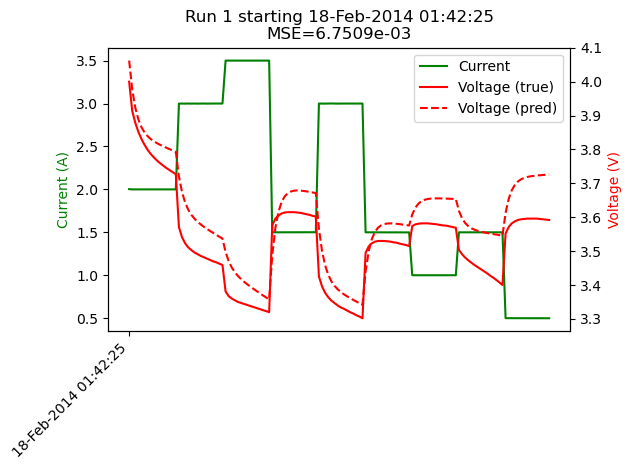

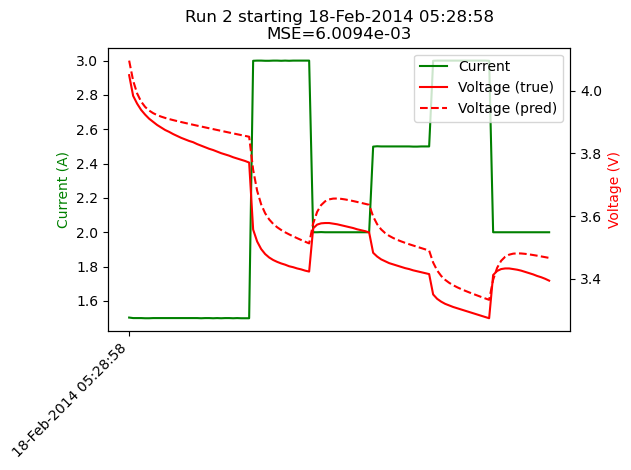

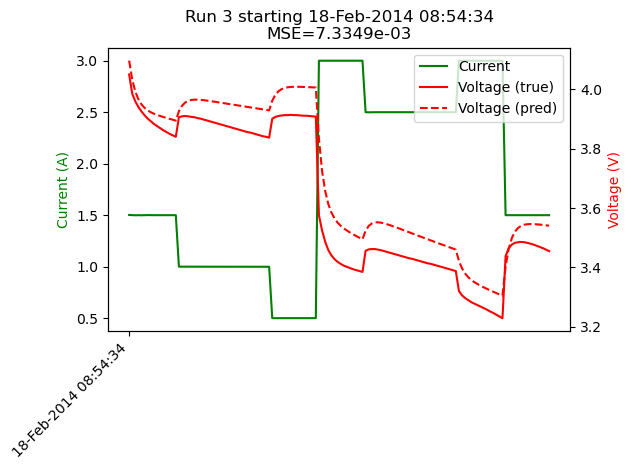

Testing on 446 runs
Test error [MAE, MAPE, MSE, RMSE]: [0.1358320564031601, 0.0384221188724041, 0.023420855402946472, 0.14473631978034973]
Test error [MAE, MAPE, MSE, RMSE]: [0.13583206 0.03842212 0.02342086 0.14473632]


In [2]:
def get_args():
    parser = argparse.ArgumentParser(description='Battery Net for NPZData')
    # — Original battery‐model params —
    parser.add_argument('--V0',        type=float, default=4.2)
    parser.add_argument('--x0',        nargs=3,   type=float, default=[8000, 0, 0])
    parser.add_argument('--dt',        type=float, default=1.0)
    parser.add_argument('--VEOD',      type=float, default=3.2)
    parser.add_argument('--Rp',        type=float, default=1000)
    parser.add_argument('--Rs',        type=float, default=0.5)
    parser.add_argument('--Csp',       type=float, default=15)
    parser.add_argument('--Cs',        type=float, default=500)

    # — Training / data params —
    parser.add_argument('--batch_size', '-n', type=int,   default=300)
    parser.add_argument('--seq_len',    '-l', type=int,   default=30)
    parser.add_argument('--npz_dir',              default='../../dataset/')

    # — Optimization params —
    parser.add_argument('--device',     default='cpu')
    parser.add_argument('--epoch',      type=int,   default=2000)
    parser.add_argument('--lr',         type=float, default=2e-2)
    parser.add_argument('--weight_decay',type=float,default=5e-4)

    # — Model selection & saving —
    parser.add_argument('--model_name', choices=['BattNN','LSTM'], default='BattNN')
    parser.add_argument('--save_model', choices=[None,'NASA'], default='NASA')

    # ignore Jupyter args
    args, _ = parser.parse_known_args()
    return args

# 1) Build args
args = get_args()
print("Arguments:", args)

# 3) Load data
data = NPZData(npz_dir=args.npz_dir,
               n=args.batch_size,
               length=args.seq_len)

train_x, train_y, train_dates = data.load_train_data()
print("Train shape:", train_x.shape, train_y.shape)

# 4) Train & test
model = train(args, train_x, train_y, model_name=args.model_name)

mean_error, errors = test(args,
                  data_iter=data.yield_test_data,
                  model_name=args.model_name,
                  plot_n=3)

np.savez(f'results/BattNN-{args.save_model}-batch_size={args.batch_size}-seq_len={args.seq_len}.npz', errors)
print("Test error [MAE, MAPE, MSE, RMSE]:", mean_error)